In [1]:
# ============================================================
# PHASE 24 — TOP-K RANKING UTILITY METRICS
# ============================================================
# Goal:
# Evaluate the project as a gene prioritization framework rather than
# only as a binary classifier.
#
# Why:
# For disease-gene prioritization, top-ranked utility is often more
# important than global ROC-AUC.
#
# This phase computes:
# - Precision@K
# - Recall@K
# - F1@K
# - HitRate@K
# - EnrichmentFactor@K
# - NDCG@K
# - Average precision among top K
# - Random baseline comparison
# - Model agreement in top K
# - Top-K utility summary for manuscript
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
PHASE19_DIR = PROJECT_DIR / "model" / "phase19_external_independent_gene_set_validation"
PHASE20_DIR = PROJECT_DIR / "model" / "phase20_pathway_network_validation"
PHASE21_DIR = PROJECT_DIR / "model" / "phase21_case_level_explainability_error_ranking_audit"
PHASE22_DIR = PROJECT_DIR / "model" / "phase22_multimodal_fusion_strategy_comparison"

PHASE24_DIR = PROJECT_DIR / "model" / "phase24_topk_ranking_utility_metrics"
RESULT_DIR = PHASE24_DIR / "results"
FIGURE_DIR = PHASE24_DIR / "figures"
EXCEL_DIR = PHASE24_DIR / "excel"
REPORT_DIR = PHASE24_DIR / "reports"

for d in [PHASE24_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 24 output:", PHASE24_DIR)

Mounted at /content/drive
Phase 24 output: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def clean_gene_symbol(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "" or s in ["NAN", "NONE", "NULL"]:
        return None
    return s


def dcg_at_k(labels, k):
    labels = np.asarray(labels)[:k]
    if len(labels) == 0:
        return 0.0

    gains = labels
    discounts = np.log2(np.arange(2, len(labels) + 2))
    return float(np.sum(gains / discounts))


def ndcg_at_k(labels_sorted_by_model, k):
    labels_sorted_by_model = np.asarray(labels_sorted_by_model).astype(int)
    dcg = dcg_at_k(labels_sorted_by_model, k)

    ideal = np.sort(labels_sorted_by_model)[::-1]
    idcg = dcg_at_k(ideal, k)

    if idcg == 0:
        return np.nan

    return float(dcg / idcg)


def average_precision_at_k(labels_sorted_by_model, k):
    labels = np.asarray(labels_sorted_by_model).astype(int)[:k]

    if labels.sum() == 0:
        return 0.0

    precisions = []
    hits = 0

    for i, rel in enumerate(labels, start=1):
        if rel == 1:
            hits += 1
            precisions.append(hits / i)

    if len(precisions) == 0:
        return 0.0

    return float(np.mean(precisions))


def topk_metrics_for_ranking(df_rank, k, label_col="true_label"):
    tmp = df_rank.sort_values("rank_desc").reset_index(drop=True)
    labels = tmp[label_col].astype(int).values
    top_labels = labels[:k]

    n_total = len(labels)
    n_pos_total = int(labels.sum())
    n_pos_top = int(top_labels.sum())

    precision_k = n_pos_top / k
    recall_k = n_pos_top / n_pos_total if n_pos_total > 0 else np.nan
    f1_k = (
        2 * precision_k * recall_k / (precision_k + recall_k)
        if (precision_k + recall_k) > 0 else 0
    )

    baseline_precision = n_pos_total / n_total if n_total > 0 else np.nan
    enrichment = precision_k / baseline_precision if baseline_precision > 0 else np.nan

    return {
        "top_k": k,
        "n_total": n_total,
        "n_positive_total": n_pos_total,
        "n_positive_in_topk": n_pos_top,
        "precision_at_k": precision_k,
        "recall_at_k": recall_k,
        "f1_at_k": f1_k,
        "hit_rate_at_k": 1.0 if n_pos_top > 0 else 0.0,
        "baseline_positive_rate": baseline_precision,
        "enrichment_factor_at_k": enrichment,
        "ndcg_at_k": ndcg_at_k(labels, k),
        "average_precision_at_k": average_precision_at_k(labels, k)
    }


def empirical_p_value(observed, random_values, alternative="greater"):
    random_values = np.asarray(random_values)

    if alternative == "greater":
        return (np.sum(random_values >= observed) + 1) / (len(random_values) + 1)

    if alternative == "less":
        return (np.sum(random_values <= observed) + 1) / (len(random_values) + 1)

    raise ValueError("alternative must be greater or less")


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng_local = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng_local.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boots, alpha)),
        float(np.percentile(boots, 100 - alpha))
    )

In [3]:
# ============================================================
# LOAD GENE-LEVEL OUT-OF-FOLD RANKINGS
# ============================================================

gene_rank_path = PHASE19_DIR / "results" / "phase19_gene_level_oof_rankings_by_model.csv"
consensus_path = PHASE19_DIR / "results" / "phase19_consensus_gene_ranking_across_models.csv"

assert gene_rank_path.exists(), f"Missing: {gene_rank_path}"
assert consensus_path.exists(), f"Missing: {consensus_path}"

gene_rank_df = pd.read_csv(gene_rank_path)
consensus_df = pd.read_csv(consensus_path)

gene_rank_df["gene_symbol"] = gene_rank_df["gene_symbol"].apply(clean_gene_symbol)
consensus_df["gene_symbol"] = consensus_df["gene_symbol"].apply(clean_gene_symbol)

display(gene_rank_df.head())
display(consensus_df.head())

print("Models:", gene_rank_df["model_name"].unique())
print("n genes:", consensus_df["gene_symbol"].nunique())
print("label counts:", consensus_df["true_label"].value_counts().to_dict())

,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name
0,386,ATP4B,1,0.897893,0.018568,5,DNABERT2_multimodal,1,1.000000,DNABERT-2 multimodal
1,1701,GRM8,1,0.892079,0.013946,5,DNABERT2_multimodal,2,0.999446,DNABERT-2 multimodal
2,21,NEXMIF,0,0.890804,0.024677,5,DNABERT2_multimodal,3,0.998892,DNABERT-2 multimodal
3,479,HAUS6,0,0.889759,0.007953,5,DNABERT2_multimodal,4,0.998338,DNABERT-2 multimodal
4,454,ZC3H13,1,0.881700,0.005782,5,DNABERT2_multimodal,5,0.997784,DNABERT-2 multimodal


,sample_index,gene_symbol,true_label,mean_percentile_rank,sd_percentile_rank,mean_rank,best_rank,consensus_rank,external_sets,n_external_sets,is_external_supported
0,386,ATP4B,1,0.995984,0.004687,8.25,1,1,NaN,0,False
1,560,VDR,1,0.991274,0.008776,16.75,1,2,NaN,0,False
2,454,ZC3H13,1,0.987950,0.011989,22.75,4,3,NaN,0,False
3,878,B4GALNT1,1,0.984626,0.015256,28.75,14,4,NaN,0,False
4,389,CACNA2D3,1,0.981025,0.018532,35.25,7,5,NaN,0,False


Models: ['DNABERT2_multimodal' 'Genomic_only_K3K4Basic' 'Handcrafted_multimodal'
 'Protein_only_ProtBERT_SW']
n genes: 1806
label counts: {1: 903, 0: 903}


In [4]:
# ============================================================
# ADD OPTIONAL PATHWAY AND EXTERNAL ANNOTATIONS
# ============================================================

pathway_annotation_path = PHASE20_DIR / "results" / "phase20_all_genes_with_pathway_annotations.csv"
external_annotation_path = PHASE19_DIR / "results" / "phase19_external_supported_genes_ranked_by_model.csv"

if pathway_annotation_path.exists():
    pathway_df = pd.read_csv(pathway_annotation_path)
    pathway_df["gene_symbol"] = pathway_df["gene_symbol"].apply(clean_gene_symbol)

    pathway_cols = [
        "gene_symbol",
        "n_curated_pathways",
        "curated_pathways",
        "is_pathway_supported"
    ]
    pathway_cols = [c for c in pathway_cols if c in pathway_df.columns]

    pathway_gene_annotation_df = pathway_df[pathway_cols].drop_duplicates("gene_symbol")
else:
    pathway_gene_annotation_df = pd.DataFrame({
        "gene_symbol": consensus_df["gene_symbol"].unique(),
        "n_curated_pathways": 0,
        "curated_pathways": "",
        "is_pathway_supported": False
    })

if external_annotation_path.exists():
    ext_df = pd.read_csv(external_annotation_path)
    ext_df["gene_symbol"] = ext_df["gene_symbol"].apply(clean_gene_symbol)

    external_gene_annotation_df = (
        ext_df
        .groupby("gene_symbol", as_index=False)
        .agg(
            n_external_sets=("n_external_sets", "max"),
            external_sets=("external_sets", "first")
        )
    )
else:
    external_gene_annotation_df = pd.DataFrame({
        "gene_symbol": consensus_df["gene_symbol"].unique(),
        "n_external_sets": 0,
        "external_sets": ""
    })

gene_rank_annotated_df = gene_rank_df.merge(
    pathway_gene_annotation_df,
    on="gene_symbol",
    how="left"
)

gene_rank_annotated_df = gene_rank_annotated_df.merge(
    external_gene_annotation_df,
    on="gene_symbol",
    how="left"
)

for col, default in [
    ("n_curated_pathways", 0),
    ("curated_pathways", ""),
    ("is_pathway_supported", False),
    ("n_external_sets", 0),
    ("external_sets", "")
]:
    if col not in gene_rank_annotated_df.columns:
        gene_rank_annotated_df[col] = default
    else:
        gene_rank_annotated_df[col] = gene_rank_annotated_df[col].fillna(default)

gene_rank_annotated_df["n_curated_pathways"] = gene_rank_annotated_df["n_curated_pathways"].astype(int)
gene_rank_annotated_df["n_external_sets"] = gene_rank_annotated_df["n_external_sets"].astype(int)
gene_rank_annotated_df["is_external_supported"] = gene_rank_annotated_df["n_external_sets"] > 0
gene_rank_annotated_df["is_pathway_supported"] = gene_rank_annotated_df["is_pathway_supported"].astype(bool)

display(gene_rank_annotated_df.head())

save_df(gene_rank_annotated_df, RESULT_DIR / "phase24_gene_rankings_with_annotations.csv")

,sample_index,gene_symbol,true_label,mean_oof_score,sd_oof_score,n_oof_predictions,model_name,rank_desc,percentile_rank,display_name,n_curated_pathways,curated_pathways,is_pathway_supported,n_external_sets,external_sets,is_external_supported
0,386,ATP4B,1,0.897893,0.018568,5,DNABERT2_multimodal,1,1.000000,DNABERT-2 multimodal,0,,False,0,,False
1,1701,GRM8,1,0.892079,0.013946,5,DNABERT2_multimodal,2,0.999446,DNABERT-2 multimodal,0,,False,0,,False
2,21,NEXMIF,0,0.890804,0.024677,5,DNABERT2_multimodal,3,0.998892,DNABERT-2 multimodal,0,,False,0,,False
3,479,HAUS6,0,0.889759,0.007953,5,DNABERT2_multimodal,4,0.998338,DNABERT-2 multimodal,0,,False,0,,False
4,454,ZC3H13,1,0.881700,0.005782,5,DNABERT2_multimodal,5,0.997784,DNABERT-2 multimodal,0,,False,0,,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_gene_rankings_with_annotations.csv


In [5]:
# ============================================================
# TOP-K UTILITY AGAINST CURRENT LABELS
# ============================================================

TOP_K_LIST = [10, 25, 50, 100, 150, 200, 300, 500]

topk_records = []

for model_name, sub in gene_rank_annotated_df.groupby("model_name"):
    sub = sub.sort_values("rank_desc").reset_index(drop=True)

    for k in TOP_K_LIST:
        if k > len(sub):
            continue

        rec = topk_metrics_for_ranking(sub, k)
        rec["model_name"] = model_name
        rec["display_name"] = sub["display_name"].iloc[0] if "display_name" in sub.columns else model_name
        rec["ranking_target"] = "current_positive_label"

        topk_records.append(rec)

topk_label_df = pd.DataFrame(topk_records)
topk_label_df = round_numeric_columns(topk_label_df, 5)

display(topk_label_df)

save_df(topk_label_df, RESULT_DIR / "phase24_topk_current_label_utility_metrics.csv")

,top_k,n_total,n_positive_total,n_positive_in_topk,precision_at_k,recall_at_k,f1_at_k,hit_rate_at_k,baseline_positive_rate,enrichment_factor_at_k,ndcg_at_k,average_precision_at_k,model_name,display_name,ranking_target
0,10,1806,903,7,0.70000,0.00775,0.01533,1.0,0.5,1.40000,0.72180,0.75119,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
1,25,1806,903,20,0.80000,0.02215,0.04310,1.0,0.5,1.60000,0.78381,0.75673,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
2,50,1806,903,44,0.88000,0.04873,0.09234,1.0,0.5,1.76000,0.84981,0.81281,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
3,100,1806,903,83,0.83000,0.09192,0.16550,1.0,0.5,1.66000,0.82346,0.83301,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
4,150,1806,903,120,0.80000,0.13289,0.22792,1.0,0.5,1.60000,0.80211,0.82669,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
5,200,1806,903,157,0.78500,0.17386,0.28468,1.0,0.5,1.57000,0.79015,0.81862,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
6,300,1806,903,240,0.80000,0.26578,0.39900,1.0,0.5,1.60000,0.80105,0.81239,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
7,500,1806,903,380,0.76000,0.42082,0.54170,1.0,0.5,1.52000,0.76794,0.79996,DNABERT2_multimodal,DNABERT-2 multimodal,current_positive_label
8,10,1806,903,9,0.90000,0.00997,0.01972,1.0,0.5,1.80000,0.77991,0.78567,Genomic_only_K3K4Basic,Genomic-only,current_positive_label
9,25,1806,903,21,0.84000,0.02326,0.04526,1.0,0.5,1.68000,0.79051,0.83771,Genomic_only_K3K4Basic,Genomic-only,current_positive_label


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_topk_current_label_utility_metrics.csv


In [6]:
# ============================================================
# TOP-K UTILITY FOR PATHWAY / EXTERNAL SUPPORT
# ============================================================
# These are not model training labels. They measure biological utility.
# ============================================================

biological_targets = {
    "pathway_supported": "is_pathway_supported",
    "external_supported": "is_external_supported",
}

bio_topk_records = []

for target_name, target_col in biological_targets.items():
    for model_name, sub in gene_rank_annotated_df.groupby("model_name"):
        sub = sub.sort_values("rank_desc").reset_index(drop=True).copy()

        if target_col not in sub.columns:
            continue

        sub["bio_label"] = sub[target_col].astype(int)

        for k in TOP_K_LIST:
            if k > len(sub):
                continue

            rec = topk_metrics_for_ranking(sub, k, label_col="bio_label")
            rec["model_name"] = model_name
            rec["display_name"] = sub["display_name"].iloc[0] if "display_name" in sub.columns else model_name
            rec["ranking_target"] = target_name

            bio_topk_records.append(rec)

topk_bio_df = pd.DataFrame(bio_topk_records)
topk_bio_df = round_numeric_columns(topk_bio_df, 5)

display(topk_bio_df.head(40))

save_df(topk_bio_df, RESULT_DIR / "phase24_topk_biological_support_utility_metrics.csv")

,top_k,n_total,n_positive_total,n_positive_in_topk,precision_at_k,recall_at_k,f1_at_k,hit_rate_at_k,baseline_positive_rate,enrichment_factor_at_k,ndcg_at_k,average_precision_at_k,model_name,display_name,ranking_target
0,10,1806,91,0,0.00000,0.00000,0.00000,0.0,0.05039,0.00000,0.00000,0.00000,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
1,25,1806,91,1,0.04000,0.01099,0.01724,1.0,0.05039,0.79385,0.02682,0.04348,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
2,50,1806,91,3,0.06000,0.03297,0.04255,1.0,0.05039,1.19077,0.04725,0.06269,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
3,100,1806,91,7,0.07000,0.07692,0.07330,1.0,0.05039,1.38923,0.06397,0.06819,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
4,150,1806,91,8,0.05333,0.08791,0.06639,1.0,0.05039,1.05846,0.07104,0.06638,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
5,200,1806,91,11,0.05500,0.12088,0.07560,1.0,0.05039,1.09154,0.09159,0.06380,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
6,300,1806,91,16,0.05333,0.17582,0.08184,1.0,0.05039,1.05846,0.12364,0.06129,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
7,500,1806,91,29,0.05800,0.31868,0.09814,1.0,0.05039,1.15108,0.20060,0.05950,DNABERT2_multimodal,DNABERT-2 multimodal,pathway_supported
8,10,1806,91,0,0.00000,0.00000,0.00000,0.0,0.05039,0.00000,0.00000,0.00000,Genomic_only_K3K4Basic,Genomic-only,pathway_supported
9,25,1806,91,0,0.00000,0.00000,0.00000,0.0,0.05039,0.00000,0.00000,0.00000,Genomic_only_K3K4Basic,Genomic-only,pathway_supported


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_topk_biological_support_utility_metrics.csv


In [7]:
# ============================================================
# RANDOM BASELINE FOR TOP-K CURRENT-LABEL RECOVERY
# ============================================================

N_RANDOM = 5000

random_baseline_records = []

for model_name, sub in gene_rank_annotated_df.groupby("model_name"):
    sub = sub.sort_values("rank_desc").reset_index(drop=True)

    labels = sub["true_label"].astype(int).values
    n_total = len(labels)
    n_pos_total = int(labels.sum())

    for k in TOP_K_LIST:
        if k > n_total:
            continue

        observed_pos = int(labels[:k].sum())
        observed_precision = observed_pos / k

        random_pos_counts = []

        for _ in range(N_RANDOM):
            rand_idx = rng.choice(np.arange(n_total), size=k, replace=False)
            random_pos_counts.append(int(labels[rand_idx].sum()))

        random_pos_counts = np.asarray(random_pos_counts)

        random_mean = random_pos_counts.mean()
        random_sd = random_pos_counts.std(ddof=1)

        p_emp = empirical_p_value(observed_pos, random_pos_counts, alternative="greater")

        random_baseline_records.append({
            "model_name": model_name,
            "display_name": sub["display_name"].iloc[0] if "display_name" in sub.columns else model_name,
            "top_k": k,
            "observed_positive_in_topk": observed_pos,
            "observed_precision_at_k": observed_precision,
            "random_mean_positive_in_topk": random_mean,
            "random_sd_positive_in_topk": random_sd,
            "fold_enrichment_vs_random": observed_pos / random_mean if random_mean > 0 else np.nan,
            "empirical_p": p_emp
        })

topk_random_df = pd.DataFrame(random_baseline_records)

topk_random_df["empirical_bh_fdr_global"] = multipletests(
    topk_random_df["empirical_p"],
    method="fdr_bh"
)[1]

topk_random_df["empirical_bh_fdr_within_topk"] = np.nan

for k, sub in topk_random_df.groupby("top_k"):
    idx = sub.index
    topk_random_df.loc[idx, "empirical_bh_fdr_within_topk"] = multipletests(
        sub["empirical_p"],
        method="fdr_bh"
    )[1]

topk_random_df = round_numeric_columns(topk_random_df, 5)

display(topk_random_df)

save_df(topk_random_df, RESULT_DIR / "phase24_topk_current_label_random_baseline.csv")

,model_name,display_name,top_k,observed_positive_in_topk,observed_precision_at_k,random_mean_positive_in_topk,random_sd_positive_in_topk,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_global,empirical_bh_fdr_within_topk
0,DNABERT2_multimodal,DNABERT-2 multimodal,10,7,0.70000,4.9858,1.58117,1.40399,0.17097,0.17217,0.17217
1,DNABERT2_multimodal,DNABERT-2 multimodal,25,20,0.80000,12.5204,2.44556,1.59739,0.00240,0.00284,0.00260
2,DNABERT2_multimodal,DNABERT-2 multimodal,50,44,0.88000,25.0434,3.48866,1.75695,0.00020,0.00027,0.00027
3,DNABERT2_multimodal,DNABERT-2 multimodal,100,83,0.83000,50.0750,4.76759,1.65751,0.00020,0.00027,0.00020
4,DNABERT2_multimodal,DNABERT-2 multimodal,150,120,0.80000,75.1218,5.83704,1.59741,0.00020,0.00027,0.00020
5,DNABERT2_multimodal,DNABERT-2 multimodal,200,157,0.78500,100.0532,6.61812,1.56917,0.00020,0.00027,0.00020
6,DNABERT2_multimodal,DNABERT-2 multimodal,300,240,0.80000,149.9300,8.05007,1.60075,0.00020,0.00027,0.00020
7,DNABERT2_multimodal,DNABERT-2 multimodal,500,380,0.76000,250.1872,9.53757,1.51886,0.00020,0.00027,0.00020
8,Genomic_only_K3K4Basic,Genomic-only,10,9,0.90000,4.9832,1.59744,1.80607,0.00980,0.01045,0.01960
9,Genomic_only_K3K4Basic,Genomic-only,25,21,0.84000,12.5080,2.49832,1.67893,0.00060,0.00074,0.00120


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_topk_current_label_random_baseline.csv


In [8]:
# ============================================================
# PAIRWISE TOP-K DIFFERENCES BETWEEN MODELS
# ============================================================

model_pairs = [
    ("DNABERT2_multimodal", "Handcrafted_multimodal"),
    ("DNABERT2_multimodal", "Protein_only_ProtBERT_SW"),
    ("Handcrafted_multimodal", "Protein_only_ProtBERT_SW"),
    ("Protein_only_ProtBERT_SW", "Genomic_only_K3K4Basic"),
]

topk_pair_records = []

metrics_to_compare = [
    "precision_at_k",
    "recall_at_k",
    "enrichment_factor_at_k",
    "ndcg_at_k",
    "average_precision_at_k"
]

for model_a, model_b in model_pairs:
    a_df = topk_label_df[topk_label_df["model_name"] == model_a]
    b_df = topk_label_df[topk_label_df["model_name"] == model_b]

    if a_df.empty or b_df.empty:
        continue

    for k in TOP_K_LIST:
        a_row = a_df[a_df["top_k"] == k]
        b_row = b_df[b_df["top_k"] == k]

        if a_row.empty or b_row.empty:
            continue

        a_row = a_row.iloc[0]
        b_row = b_row.iloc[0]

        for metric in metrics_to_compare:
            topk_pair_records.append({
                "comparison": f"{model_a} minus {model_b}",
                "model_a": model_a,
                "model_b": model_b,
                "top_k": k,
                "metric": metric,
                "model_a_value": a_row[metric],
                "model_b_value": b_row[metric],
                "delta": a_row[metric] - b_row[metric]
            })

topk_pairwise_df = pd.DataFrame(topk_pair_records)
topk_pairwise_df = round_numeric_columns(topk_pairwise_df, 5)

display(topk_pairwise_df.head(60))

save_df(topk_pairwise_df, RESULT_DIR / "phase24_pairwise_topk_metric_differences.csv")

,comparison,model_a,model_b,top_k,metric,model_a_value,model_b_value,delta
0,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,10,precision_at_k,0.70000,0.90000,-0.20000
1,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,10,recall_at_k,0.00775,0.00997,-0.00222
2,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,10,enrichment_factor_at_k,1.40000,1.80000,-0.40000
3,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,10,ndcg_at_k,0.72180,0.92160,-0.19980
4,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,10,average_precision_at_k,0.75119,0.94678,-0.19559
5,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,25,precision_at_k,0.80000,0.92000,-0.12000
6,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,25,recall_at_k,0.02215,0.02547,-0.00332
7,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,25,enrichment_factor_at_k,1.60000,1.84000,-0.24000
8,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,25,ndcg_at_k,0.78381,0.92611,-0.14230
9,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,25,average_precision_at_k,0.75673,0.92440,-0.16767


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_pairwise_topk_metric_differences.csv


In [9]:
# ============================================================
# TOP-K GENE LISTS FOR MANUSCRIPT INSPECTION
# ============================================================

EXPORT_TOP_K = 100

top_gene_records = []

for model_name, sub in gene_rank_annotated_df.groupby("model_name"):
    sub = sub.sort_values("rank_desc").head(EXPORT_TOP_K).copy()
    sub["top_k_export"] = EXPORT_TOP_K

    top_gene_records.append(sub)

top100_genes_by_model_df = pd.concat(top_gene_records, ignore_index=True)

top100_genes_by_model_df = top100_genes_by_model_df[[
    "model_name",
    "display_name",
    "rank_desc",
    "gene_symbol",
    "true_label",
    "mean_oof_score",
    "percentile_rank",
    "n_curated_pathways",
    "curated_pathways",
    "n_external_sets",
    "external_sets",
    "is_pathway_supported",
    "is_external_supported"
]]

top100_genes_by_model_df = round_numeric_columns(top100_genes_by_model_df, 6)

display(top100_genes_by_model_df.head(40))

save_df(top100_genes_by_model_df, RESULT_DIR / "phase24_top100_gene_lists_by_model_with_annotations.csv")

,model_name,display_name,rank_desc,gene_symbol,true_label,mean_oof_score,percentile_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,is_pathway_supported,is_external_supported
0,DNABERT2_multimodal,DNABERT-2 multimodal,1,ATP4B,1,0.897893,1.000000,0,,0,,False,False
1,DNABERT2_multimodal,DNABERT-2 multimodal,2,GRM8,1,0.892079,0.999446,0,,0,,False,False
2,DNABERT2_multimodal,DNABERT-2 multimodal,3,NEXMIF,0,0.890804,0.998892,0,,0,,False,False
3,DNABERT2_multimodal,DNABERT-2 multimodal,4,HAUS6,0,0.889759,0.998338,0,,0,,False,False
4,DNABERT2_multimodal,DNABERT-2 multimodal,5,ZC3H13,1,0.881700,0.997784,0,,0,,False,False
5,DNABERT2_multimodal,DNABERT-2 multimodal,6,RBM27,1,0.879396,0.997230,0,,0,,False,False
6,DNABERT2_multimodal,DNABERT-2 multimodal,7,PNLIP,0,0.877368,0.996676,0,,0,,False,False
7,DNABERT2_multimodal,DNABERT-2 multimodal,8,MLXIPL,1,0.876813,0.996122,0,,0,,False,False
8,DNABERT2_multimodal,DNABERT-2 multimodal,9,DENND2A,1,0.876118,0.995568,0,,0,,False,False
9,DNABERT2_multimodal,DNABERT-2 multimodal,10,RAET1L,1,0.875945,0.995014,0,,0,,False,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_top100_gene_lists_by_model_with_annotations.csv


In [10]:
# ============================================================
# MODEL AGREEMENT IN TOP-K
# ============================================================

agreement_records = []

models = sorted(gene_rank_annotated_df["model_name"].unique())

for k in TOP_K_LIST:
    top_sets = {}

    for model in models:
        sub = gene_rank_annotated_df[gene_rank_annotated_df["model_name"] == model].sort_values("rank_desc")
        top_sets[model] = set(sub.head(k)["gene_symbol"].astype(str).tolist())

    for i, model_a in enumerate(models):
        for model_b in models[i+1:]:
            inter = top_sets[model_a].intersection(top_sets[model_b])
            union = top_sets[model_a].union(top_sets[model_b])

            agreement_records.append({
                "top_k": k,
                "model_a": model_a,
                "model_b": model_b,
                "n_overlap": len(inter),
                "jaccard": len(inter) / len(union) if len(union) > 0 else np.nan,
                "overlap_genes": "; ".join(sorted(inter))
            })

topk_agreement_df = pd.DataFrame(agreement_records)
topk_agreement_df = round_numeric_columns(topk_agreement_df, 5)

display(topk_agreement_df.head(40))

save_df(topk_agreement_df, RESULT_DIR / "phase24_topk_model_agreement_jaccard.csv")

,top_k,model_a,model_b,n_overlap,jaccard,overlap_genes
0,10,DNABERT2_multimodal,Genomic_only_K3K4Basic,0,0.00000,
1,10,DNABERT2_multimodal,Handcrafted_multimodal,4,0.25000,ATP4B; GRM8; NEXMIF; ZC3H13
2,10,DNABERT2_multimodal,Protein_only_ProtBERT_SW,2,0.11111,GRM8; NEXMIF
3,10,Genomic_only_K3K4Basic,Handcrafted_multimodal,1,0.05263,VDR
4,10,Genomic_only_K3K4Basic,Protein_only_ProtBERT_SW,0,0.00000,
5,10,Handcrafted_multimodal,Protein_only_ProtBERT_SW,3,0.17647,GCKR; GRM8; NEXMIF
6,25,DNABERT2_multimodal,Genomic_only_K3K4Basic,2,0.04167,ATP4B; B4GALNT1
7,25,DNABERT2_multimodal,Handcrafted_multimodal,11,0.28205,ATP4B; B4GALNT1; DENND2A; ETS1; FEZF1; GRM8; HAUS6; MLXIPL; NEXMIF; NSD3; ZC3H13
8,25,DNABERT2_multimodal,Protein_only_ProtBERT_SW,6,0.13636,ATP4B; FEZF1; GRM8; HAUS6; MLXIPL; NEXMIF
9,25,Genomic_only_K3K4Basic,Handcrafted_multimodal,4,0.08696,ATP4B; B4GALNT1; COBLL1; VDR


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_topk_model_agreement_jaccard.csv


In [11]:
# ============================================================
# COMPACT MANUSCRIPT SUMMARY TABLES
# ============================================================

MAIN_TOP_K = [25, 50, 100, 200]

manuscript_current_label_df = topk_label_df[
    topk_label_df["top_k"].isin(MAIN_TOP_K)
].copy()

manuscript_current_label_df = manuscript_current_label_df[[
    "display_name",
    "model_name",
    "top_k",
    "n_positive_in_topk",
    "precision_at_k",
    "recall_at_k",
    "enrichment_factor_at_k",
    "ndcg_at_k",
    "average_precision_at_k"
]].sort_values(["top_k", "precision_at_k"], ascending=[True, False])

manuscript_current_label_df = round_numeric_columns(manuscript_current_label_df, 4)

display(manuscript_current_label_df)

save_df(
    manuscript_current_label_df,
    RESULT_DIR / "phase24_manuscript_topk_current_label_utility_table.csv"
)


manuscript_random_df = topk_random_df[
    topk_random_df["top_k"].isin(MAIN_TOP_K)
].copy()

manuscript_random_df = manuscript_random_df[[
    "display_name",
    "model_name",
    "top_k",
    "observed_positive_in_topk",
    "random_mean_positive_in_topk",
    "fold_enrichment_vs_random",
    "empirical_p",
    "empirical_bh_fdr_within_topk"
]].sort_values(["top_k", "fold_enrichment_vs_random"], ascending=[True, False])

manuscript_random_df = round_numeric_columns(manuscript_random_df, 4)

display(manuscript_random_df)

save_df(
    manuscript_random_df,
    RESULT_DIR / "phase24_manuscript_topk_random_baseline_table.csv"
)


manuscript_bio_df = topk_bio_df[
    topk_bio_df["top_k"].isin(MAIN_TOP_K)
].copy()

manuscript_bio_df = manuscript_bio_df[[
    "display_name",
    "model_name",
    "ranking_target",
    "top_k",
    "n_positive_in_topk",
    "precision_at_k",
    "recall_at_k",
    "enrichment_factor_at_k",
    "ndcg_at_k"
]].sort_values(["ranking_target", "top_k", "precision_at_k"], ascending=[True, True, False])

manuscript_bio_df = round_numeric_columns(manuscript_bio_df, 4)

display(manuscript_bio_df)

save_df(
    manuscript_bio_df,
    RESULT_DIR / "phase24_manuscript_topk_biological_support_table.csv"
)

,display_name,model_name,top_k,n_positive_in_topk,precision_at_k,recall_at_k,enrichment_factor_at_k,ndcg_at_k,average_precision_at_k
17,Handcrafted multimodal,Handcrafted_multimodal,25,23,0.920,0.0255,1.84,0.9261,0.9244
9,Genomic-only,Genomic_only_K3K4Basic,25,21,0.840,0.0233,1.68,0.7905,0.8377
1,DNABERT-2 multimodal,DNABERT2_multimodal,25,20,0.800,0.0222,1.60,0.7838,0.7567
25,Protein-only,Protein_only_ProtBERT_SW,25,20,0.800,0.0222,1.60,0.7158,0.7141
2,DNABERT-2 multimodal,DNABERT2_multimodal,50,44,0.880,0.0487,1.76,0.8498,0.8128
26,Protein-only,Protein_only_ProtBERT_SW,50,41,0.820,0.0454,1.64,0.7578,0.7472
18,Handcrafted multimodal,Handcrafted_multimodal,50,39,0.780,0.0432,1.56,0.8184,0.8778
10,Genomic-only,Genomic_only_K3K4Basic,50,38,0.760,0.0421,1.52,0.7488,0.8134
19,Handcrafted multimodal,Handcrafted_multimodal,100,84,0.840,0.0930,1.68,0.8498,0.8463
3,DNABERT-2 multimodal,DNABERT2_multimodal,100,83,0.830,0.0919,1.66,0.8235,0.8330


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_manuscript_topk_current_label_utility_table.csv


,display_name,model_name,top_k,observed_positive_in_topk,random_mean_positive_in_topk,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topk
17,Handcrafted multimodal,Handcrafted_multimodal,25,23,12.5278,1.8359,0.0002,0.0008
9,Genomic-only,Genomic_only_K3K4Basic,25,21,12.5080,1.6789,0.0006,0.0012
25,Protein-only,Protein_only_ProtBERT_SW,25,20,12.4708,1.6038,0.0026,0.0026
1,DNABERT-2 multimodal,DNABERT2_multimodal,25,20,12.5204,1.5974,0.0024,0.0026
2,DNABERT-2 multimodal,DNABERT2_multimodal,50,44,25.0434,1.7570,0.0002,0.0003
26,Protein-only,Protein_only_ProtBERT_SW,50,41,25.0200,1.6387,0.0002,0.0003
18,Handcrafted multimodal,Handcrafted_multimodal,50,39,25.0570,1.5564,0.0004,0.0004
10,Genomic-only,Genomic_only_K3K4Basic,50,38,24.9866,1.5208,0.0002,0.0003
19,Handcrafted multimodal,Handcrafted_multimodal,100,84,50.0904,1.6770,0.0002,0.0002
3,DNABERT-2 multimodal,DNABERT2_multimodal,100,83,50.0750,1.6575,0.0002,0.0002


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_manuscript_topk_random_baseline_table.csv


,display_name,model_name,ranking_target,top_k,n_positive_in_topk,precision_at_k,recall_at_k,enrichment_factor_at_k,ndcg_at_k
33,DNABERT-2 multimodal,DNABERT2_multimodal,external_supported,25,1,0.040,0.0110,0.7938,0.0268
49,Handcrafted multimodal,Handcrafted_multimodal,external_supported,25,1,0.040,0.0110,0.7938,0.0356
57,Protein-only,Protein_only_ProtBERT_SW,external_supported,25,1,0.040,0.0110,0.7938,0.0438
41,Genomic-only,Genomic_only_K3K4Basic,external_supported,25,0,0.000,0.0000,0.0000,0.0000
34,DNABERT-2 multimodal,DNABERT2_multimodal,external_supported,50,3,0.060,0.0330,1.1908,0.0472
42,Genomic-only,Genomic_only_K3K4Basic,external_supported,50,3,0.060,0.0330,1.1908,0.0435
50,Handcrafted multimodal,Handcrafted_multimodal,external_supported,50,2,0.040,0.0220,0.7938,0.0384
58,Protein-only,Protein_only_ProtBERT_SW,external_supported,50,2,0.040,0.0220,0.7938,0.0422
35,DNABERT-2 multimodal,DNABERT2_multimodal,external_supported,100,7,0.070,0.0769,1.3892,0.0640
43,Genomic-only,Genomic_only_K3K4Basic,external_supported,100,4,0.040,0.0440,0.7938,0.0366


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_manuscript_topk_biological_support_table.csv


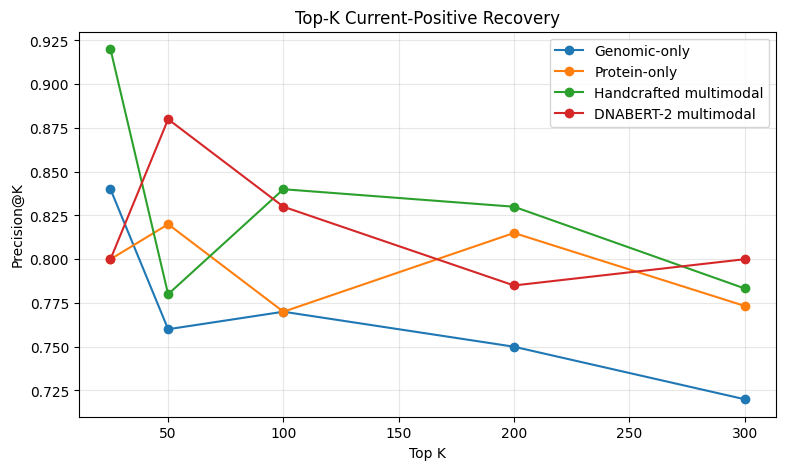

Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_precision_at_k_current_positive_recovery.png


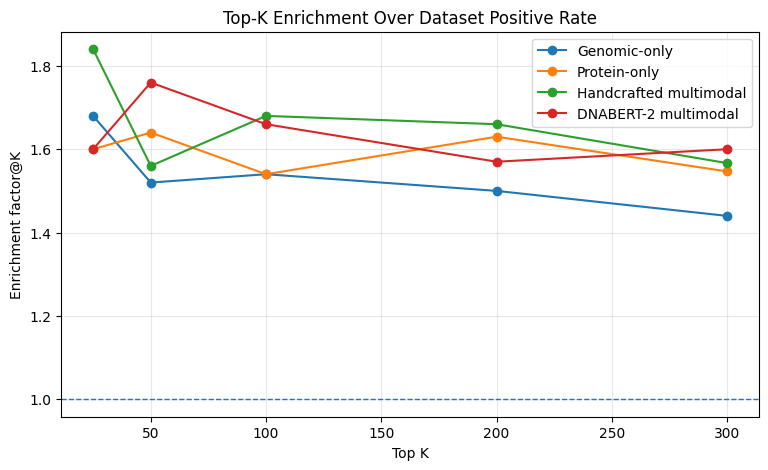

Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_enrichment_factor_at_k_current_positive_recovery.png


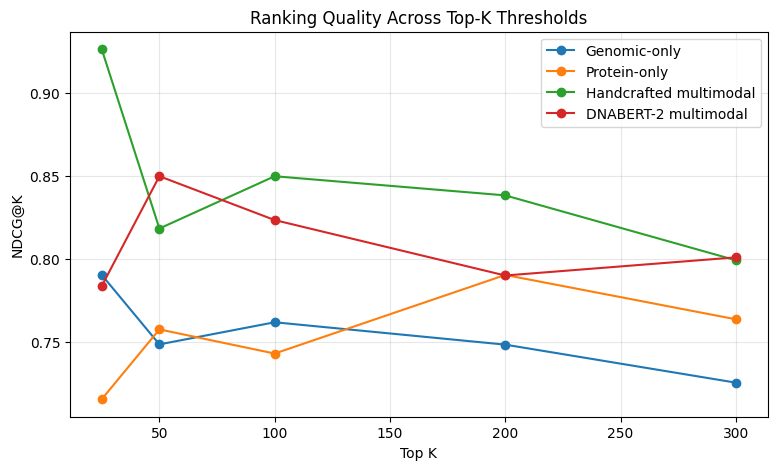

Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_ndcg_at_k_current_positive_recovery.png


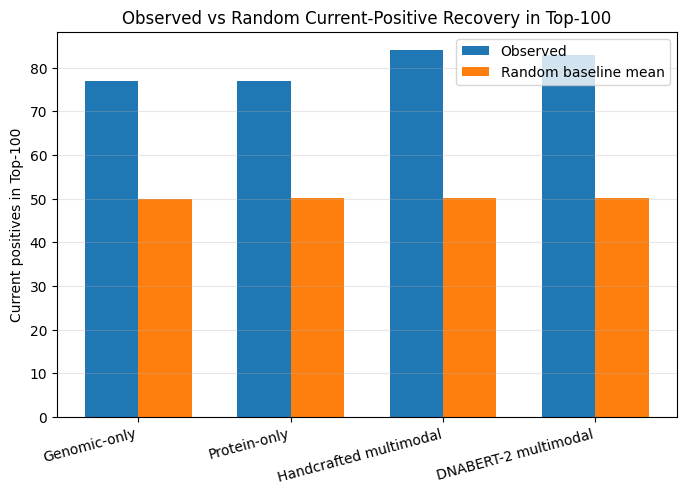

Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_top100_observed_vs_random_current_positive_recovery.png


In [12]:
# ============================================================
# FIGURES
# ============================================================

# Display order
model_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

# ------------------------------------------------------------
# Figure 1: Precision@K
# ------------------------------------------------------------

plot_df = topk_label_df.copy()
plot_df = plot_df[plot_df["top_k"].isin([25, 50, 100, 200, 300])]

plt.figure(figsize=(9, 5))

for model in model_order:
    sub = plot_df[plot_df["display_name"] == model].sort_values("top_k")
    if sub.empty:
        continue
    plt.plot(sub["top_k"], sub["precision_at_k"], marker="o", label=model)

plt.xlabel("Top K")
plt.ylabel("Precision@K")
plt.title("Top-K Current-Positive Recovery")
plt.grid(alpha=0.3)
plt.legend()

out_path = FIGURE_DIR / "phase24_precision_at_k_current_positive_recovery.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Figure 2: Enrichment factor@K
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for model in model_order:
    sub = plot_df[plot_df["display_name"] == model].sort_values("top_k")
    if sub.empty:
        continue
    plt.plot(sub["top_k"], sub["enrichment_factor_at_k"], marker="o", label=model)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Top K")
plt.ylabel("Enrichment factor@K")
plt.title("Top-K Enrichment Over Dataset Positive Rate")
plt.grid(alpha=0.3)
plt.legend()

out_path = FIGURE_DIR / "phase24_enrichment_factor_at_k_current_positive_recovery.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Figure 3: NDCG@K
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for model in model_order:
    sub = plot_df[plot_df["display_name"] == model].sort_values("top_k")
    if sub.empty:
        continue
    plt.plot(sub["top_k"], sub["ndcg_at_k"], marker="o", label=model)

plt.xlabel("Top K")
plt.ylabel("NDCG@K")
plt.title("Ranking Quality Across Top-K Thresholds")
plt.grid(alpha=0.3)
plt.legend()

out_path = FIGURE_DIR / "phase24_ndcg_at_k_current_positive_recovery.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Figure 4: Observed vs random positives in Top-100
# ------------------------------------------------------------

PLOT_TOP_K = 100

plot_df2 = manuscript_random_df[manuscript_random_df["top_k"] == PLOT_TOP_K].copy()
plot_df2["display_name"] = pd.Categorical(plot_df2["display_name"], categories=model_order, ordered=True)
plot_df2 = plot_df2.sort_values("display_name")

x = np.arange(len(plot_df2))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, plot_df2["observed_positive_in_topk"], width=width, label="Observed")
plt.bar(x + width/2, plot_df2["random_mean_positive_in_topk"], width=width, label="Random baseline mean")

plt.xticks(x, plot_df2["display_name"], rotation=15, ha="right")
plt.ylabel(f"Current positives in Top-{PLOT_TOP_K}")
plt.title(f"Observed vs Random Current-Positive Recovery in Top-{PLOT_TOP_K}")
plt.grid(axis="y", alpha=0.3)
plt.legend()

out_path = FIGURE_DIR / f"phase24_top{PLOT_TOP_K}_observed_vs_random_current_positive_recovery.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [13]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

top100 = manuscript_current_label_df[manuscript_current_label_df["top_k"] == 100].copy()
best_top100_precision = top100.sort_values("precision_at_k", ascending=False).iloc[0]

random_top100 = manuscript_random_df[manuscript_random_df["top_k"] == 100].copy()
best_random_top100 = random_top100.sort_values("fold_enrichment_vs_random", ascending=False).iloc[0]

methods_text = """
To evaluate practical gene-prioritization utility, model rankings were assessed using Top-K metrics in addition to global ROC-AUC and PR-AUC. For each model, out-of-fold gene-level scores were converted into ranked gene lists, and Precision@K, Recall@K, F1@K, HitRate@K, enrichment factor@K, NDCG@K and average precision@K were computed across multiple K thresholds. Random same-size gene sets sampled from the candidate universe were used as empirical baselines for Top-K current-positive recovery. Additional Top-K analyses were performed for pathway-supported and external-supported genes to assess biological prioritization utility.
""".strip()

results_text = f"""
Top-K ranking analysis showed that the strongest Top-100 precision was achieved by {best_top100_precision['display_name']}, with {int(best_top100_precision['n_positive_in_topk'])} current-positive genes in the Top-100 and Precision@100 of {best_top100_precision['precision_at_k']:.3f}. Against random same-size gene sets, the strongest Top-100 enrichment was observed for {best_random_top100['display_name']}, with {int(best_random_top100['observed_positive_in_topk'])} observed current positives compared with a random expectation of {best_random_top100['random_mean_positive_in_topk']:.2f}. These Top-K metrics provide a prioritization-oriented view of model utility that complements global discrimination metrics.
""".strip()

discussion_text = """
Top-K utility metrics are particularly relevant for disease-gene prioritization because downstream users typically inspect a limited number of highly ranked candidates rather than relying on a single binary threshold. If multimodal models improve Precision@K, enrichment factor@K or NDCG@K relative to protein-only and genomic-only baselines, this supports the practical value of multimodal ranking even when global metric gains are modest. These results should be interpreted under the known limitation that current positive labels are incomplete; therefore, high-ranked negative-labelled genes may include unknown positives or hypothesis-generating candidates.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Top-K Ranking Utility", "text": methods_text},
    {"section": "Results - Top-K Gene Prioritization", "text": results_text},
    {"section": "Discussion - Ranking Utility Interpretation", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase24_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase24_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Top-K Ranking Utility,"To evaluate practical gene-prioritization utility, model rankings were assessed using Top-K metrics in addition to global ROC-AUC and PR-AUC. For each model, out-of-fold gene-level scores were converted into ranked gene lists, and Precision@K, Recall@K, F1@K, HitRate@K, enrichment factor@K, NDCG@K and average precision@K were computed across multiple K thresholds. Random same-size gene sets sa..."
1,Results - Top-K Gene Prioritization,"Top-K ranking analysis showed that the strongest Top-100 precision was achieved by Handcrafted multimodal, with 84 current-positive genes in the Top-100 and Precision@100 of 0.840. Against random same-size gene sets, the strongest Top-100 enrichment was observed for Handcrafted multimodal, with 84 observed current positives compared with a random expectation of 50.09. These Top-K metrics provi..."
2,Discussion - Ranking Utility Interpretation,"Top-K utility metrics are particularly relevant for disease-gene prioritization because downstream users typically inspect a limited number of highly ranked candidates rather than relying on a single binary threshold. If multimodal models improve Precision@K, enrichment factor@K or NDCG@K relative to protein-only and genomic-only baselines, this supports the practical value of multimodal ranki..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_manuscript_ready_wording.csv
Saved manuscript wording.


In [14]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase24_topk_ranking_utility_metrics_tables.xlsx"

tables = {
    "Gene_Rankings_Annotated": gene_rank_annotated_df,
    "TopK_Current_Label": topk_label_df,
    "TopK_Biological_Support": topk_bio_df,
    "TopK_Random_Baseline": topk_random_df,
    "TopK_Pairwise_Differences": topk_pairwise_df,
    "Top100_Gene_Lists": top100_genes_by_model_df,
    "TopK_Model_Agreement": topk_agreement_df,
    "Manuscript_Current_Label": manuscript_current_label_df,
    "Manuscript_Random": manuscript_random_df,
    "Manuscript_Biological": manuscript_bio_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/excel/phase24_topk_ranking_utility_metrics_tables.xlsx


In [15]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 24 COMPLETE ===")

print("\nTop-K current-label utility:")
display(manuscript_current_label_df)

print("\nTop-K random baseline:")
display(manuscript_random_df)

print("\nTop-K biological support utility:")
display(manuscript_bio_df)

print("\nPairwise Top-K differences:")
display(topk_pairwise_df.head(80))

print("\nTop-100 genes by model:")
display(top100_genes_by_model_df.head(80))

print("\nTop-K model agreement:")
display(topk_agreement_df.head(80))

print("\nWording:")
display(wording_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 24 COMPLETE ===

Top-K current-label utility:


,display_name,model_name,top_k,n_positive_in_topk,precision_at_k,recall_at_k,enrichment_factor_at_k,ndcg_at_k,average_precision_at_k
17,Handcrafted multimodal,Handcrafted_multimodal,25,23,0.920,0.0255,1.84,0.9261,0.9244
9,Genomic-only,Genomic_only_K3K4Basic,25,21,0.840,0.0233,1.68,0.7905,0.8377
1,DNABERT-2 multimodal,DNABERT2_multimodal,25,20,0.800,0.0222,1.60,0.7838,0.7567
25,Protein-only,Protein_only_ProtBERT_SW,25,20,0.800,0.0222,1.60,0.7158,0.7141
2,DNABERT-2 multimodal,DNABERT2_multimodal,50,44,0.880,0.0487,1.76,0.8498,0.8128
26,Protein-only,Protein_only_ProtBERT_SW,50,41,0.820,0.0454,1.64,0.7578,0.7472
18,Handcrafted multimodal,Handcrafted_multimodal,50,39,0.780,0.0432,1.56,0.8184,0.8778
10,Genomic-only,Genomic_only_K3K4Basic,50,38,0.760,0.0421,1.52,0.7488,0.8134
19,Handcrafted multimodal,Handcrafted_multimodal,100,84,0.840,0.0930,1.68,0.8498,0.8463
3,DNABERT-2 multimodal,DNABERT2_multimodal,100,83,0.830,0.0919,1.66,0.8235,0.8330



Top-K random baseline:


,display_name,model_name,top_k,observed_positive_in_topk,random_mean_positive_in_topk,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topk
17,Handcrafted multimodal,Handcrafted_multimodal,25,23,12.5278,1.8359,0.0002,0.0008
9,Genomic-only,Genomic_only_K3K4Basic,25,21,12.5080,1.6789,0.0006,0.0012
25,Protein-only,Protein_only_ProtBERT_SW,25,20,12.4708,1.6038,0.0026,0.0026
1,DNABERT-2 multimodal,DNABERT2_multimodal,25,20,12.5204,1.5974,0.0024,0.0026
2,DNABERT-2 multimodal,DNABERT2_multimodal,50,44,25.0434,1.7570,0.0002,0.0003
26,Protein-only,Protein_only_ProtBERT_SW,50,41,25.0200,1.6387,0.0002,0.0003
18,Handcrafted multimodal,Handcrafted_multimodal,50,39,25.0570,1.5564,0.0004,0.0004
10,Genomic-only,Genomic_only_K3K4Basic,50,38,24.9866,1.5208,0.0002,0.0003
19,Handcrafted multimodal,Handcrafted_multimodal,100,84,50.0904,1.6770,0.0002,0.0002
3,DNABERT-2 multimodal,DNABERT2_multimodal,100,83,50.0750,1.6575,0.0002,0.0002



Top-K biological support utility:


...


Top-K model agreement:


,top_k,model_a,model_b,n_overlap,jaccard,overlap_genes
0,10,DNABERT2_multimodal,Genomic_only_K3K4Basic,0,0.00000,
1,10,DNABERT2_multimodal,Handcrafted_multimodal,4,0.25000,ATP4B; GRM8; NEXMIF; ZC3H13
2,10,DNABERT2_multimodal,Protein_only_ProtBERT_SW,2,0.11111,GRM8; NEXMIF
3,10,Genomic_only_K3K4Basic,Handcrafted_multimodal,1,0.05263,VDR
4,10,Genomic_only_K3K4Basic,Protein_only_ProtBERT_SW,0,0.00000,
5,10,Handcrafted_multimodal,Protein_only_ProtBERT_SW,3,0.17647,GCKR; GRM8; NEXMIF
6,25,DNABERT2_multimodal,Genomic_only_K3K4Basic,2,0.04167,ATP4B; B4GALNT1
7,25,DNABERT2_multimodal,Handcrafted_multimodal,11,0.28205,ATP4B; B4GALNT1; DENND2A; ETS1; FEZF1; GRM8; HAUS6; MLXIPL; NEXMIF; NSD3; ZC3H13
8,25,DNABERT2_multimodal,Protein_only_ProtBERT_SW,6,0.13636,ATP4B; FEZF1; GRM8; HAUS6; MLXIPL; NEXMIF
9,25,Genomic_only_K3K4Basic,Handcrafted_multimodal,4,0.08696,ATP4B; B4GALNT1; COBLL1; VDR



Wording:


,section,text
0,Methods - Top-K Ranking Utility,"To evaluate practical gene-prioritization utility, model rankings were assessed using Top-K metrics in addition to global ROC-AUC and PR-AUC. For each model, out-of-fold gene-level scores were converted into ranked gene lists, and Precision@K, Recall@K, F1@K, HitRate@K, enrichment factor@K, NDCG@K and average precision@K were computed across multiple K thresholds. Random same-size gene sets sa..."
1,Results - Top-K Gene Prioritization,"Top-K ranking analysis showed that the strongest Top-100 precision was achieved by Handcrafted multimodal, with 84 current-positive genes in the Top-100 and Precision@100 of 0.840. Against random same-size gene sets, the strongest Top-100 enrichment was observed for Handcrafted multimodal, with 84 observed current positives compared with a random expectation of 50.09. These Top-K metrics provi..."
2,Discussion - Ranking Utility Interpretation,"Top-K utility metrics are particularly relevant for disease-gene prioritization because downstream users typically inspect a limited number of highly ranked candidates rather than relying on a single binary threshold. If multimodal models improve Precision@K, enrichment factor@K or NDCG@K relative to protein-only and genomic-only baselines, this supports the practical value of multimodal ranki..."



Figures:
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_enrichment_factor_at_k_current_positive_recovery.png
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_ndcg_at_k_current_positive_recovery.png
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_precision_at_k_current_positive_recovery.png
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/figures/phase24_top100_observed_vs_random_current_positive_recovery.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_gene_rankings_with_annotations.csv
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_manuscript_ready_wording.csv
/content/drive/MyDrive/Project_Protein/model/phase24_topk_ranking_utility_metrics/results/phase24_manuscript_topk_biological_support_t

In [16]:
display(manuscript_current_label_df)

display(manuscript_random_df)

display(manuscript_bio_df)

display(topk_pairwise_df[
    (topk_pairwise_df["top_k"].isin([50, 100, 200])) &
    (topk_pairwise_df["metric"].isin([
        "precision_at_k",
        "enrichment_factor_at_k",
        "ndcg_at_k"
    ]))
])

display(top100_genes_by_model_df.head(100))

display(topk_agreement_df[topk_agreement_df["top_k"].isin([50, 100, 200])])

,display_name,model_name,top_k,n_positive_in_topk,precision_at_k,recall_at_k,enrichment_factor_at_k,ndcg_at_k,average_precision_at_k
17,Handcrafted multimodal,Handcrafted_multimodal,25,23,0.920,0.0255,1.84,0.9261,0.9244
9,Genomic-only,Genomic_only_K3K4Basic,25,21,0.840,0.0233,1.68,0.7905,0.8377
1,DNABERT-2 multimodal,DNABERT2_multimodal,25,20,0.800,0.0222,1.60,0.7838,0.7567
25,Protein-only,Protein_only_ProtBERT_SW,25,20,0.800,0.0222,1.60,0.7158,0.7141
2,DNABERT-2 multimodal,DNABERT2_multimodal,50,44,0.880,0.0487,1.76,0.8498,0.8128
26,Protein-only,Protein_only_ProtBERT_SW,50,41,0.820,0.0454,1.64,0.7578,0.7472
18,Handcrafted multimodal,Handcrafted_multimodal,50,39,0.780,0.0432,1.56,0.8184,0.8778
10,Genomic-only,Genomic_only_K3K4Basic,50,38,0.760,0.0421,1.52,0.7488,0.8134
19,Handcrafted multimodal,Handcrafted_multimodal,100,84,0.840,0.0930,1.68,0.8498,0.8463
3,DNABERT-2 multimodal,DNABERT2_multimodal,100,83,0.830,0.0919,1.66,0.8235,0.8330


,display_name,model_name,top_k,observed_positive_in_topk,random_mean_positive_in_topk,fold_enrichment_vs_random,empirical_p,empirical_bh_fdr_within_topk
17,Handcrafted multimodal,Handcrafted_multimodal,25,23,12.5278,1.8359,0.0002,0.0008
9,Genomic-only,Genomic_only_K3K4Basic,25,21,12.5080,1.6789,0.0006,0.0012
25,Protein-only,Protein_only_ProtBERT_SW,25,20,12.4708,1.6038,0.0026,0.0026
1,DNABERT-2 multimodal,DNABERT2_multimodal,25,20,12.5204,1.5974,0.0024,0.0026
2,DNABERT-2 multimodal,DNABERT2_multimodal,50,44,25.0434,1.7570,0.0002,0.0003
26,Protein-only,Protein_only_ProtBERT_SW,50,41,25.0200,1.6387,0.0002,0.0003
18,Handcrafted multimodal,Handcrafted_multimodal,50,39,25.0570,1.5564,0.0004,0.0004
10,Genomic-only,Genomic_only_K3K4Basic,50,38,24.9866,1.5208,0.0002,0.0003
19,Handcrafted multimodal,Handcrafted_multimodal,100,84,50.0904,1.6770,0.0002,0.0002
3,DNABERT-2 multimodal,DNABERT2_multimodal,100,83,50.0750,1.6575,0.0002,0.0002


,display_name,model_name,ranking_target,top_k,n_positive_in_topk,precision_at_k,recall_at_k,enrichment_factor_at_k,ndcg_at_k
33,DNABERT-2 multimodal,DNABERT2_multimodal,external_supported,25,1,0.040,0.0110,0.7938,0.0268
49,Handcrafted multimodal,Handcrafted_multimodal,external_supported,25,1,0.040,0.0110,0.7938,0.0356
57,Protein-only,Protein_only_ProtBERT_SW,external_supported,25,1,0.040,0.0110,0.7938,0.0438
41,Genomic-only,Genomic_only_K3K4Basic,external_supported,25,0,0.000,0.0000,0.0000,0.0000
34,DNABERT-2 multimodal,DNABERT2_multimodal,external_supported,50,3,0.060,0.0330,1.1908,0.0472
42,Genomic-only,Genomic_only_K3K4Basic,external_supported,50,3,0.060,0.0330,1.1908,0.0435
50,Handcrafted multimodal,Handcrafted_multimodal,external_supported,50,2,0.040,0.0220,0.7938,0.0384
58,Protein-only,Protein_only_ProtBERT_SW,external_supported,50,2,0.040,0.0220,0.7938,0.0422
35,DNABERT-2 multimodal,DNABERT2_multimodal,external_supported,100,7,0.070,0.0769,1.3892,0.0640
43,Genomic-only,Genomic_only_K3K4Basic,external_supported,100,4,0.040,0.0440,0.7938,0.0366


,comparison,model_a,model_b,top_k,metric,model_a_value,model_b_value,delta
10,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,50,precision_at_k,0.88000,0.78000,0.10000
12,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,50,enrichment_factor_at_k,1.76000,1.56000,0.20000
13,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,50,ndcg_at_k,0.84981,0.81838,0.03143
15,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,100,precision_at_k,0.83000,0.84000,-0.01000
17,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,100,enrichment_factor_at_k,1.66000,1.68000,-0.02000
18,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,100,ndcg_at_k,0.82346,0.84979,-0.02633
25,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,200,precision_at_k,0.78500,0.83000,-0.04500
27,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,200,enrichment_factor_at_k,1.57000,1.66000,-0.09000
28,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,200,ndcg_at_k,0.79015,0.83829,-0.04814
50,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,50,precision_at_k,0.88000,0.82000,0.06000


,model_name,display_name,rank_desc,gene_symbol,true_label,mean_oof_score,percentile_rank,n_curated_pathways,curated_pathways,n_external_sets,external_sets,is_pathway_supported,is_external_supported
0,DNABERT2_multimodal,DNABERT-2 multimodal,1,ATP4B,1,0.897893,1.000000,0,,0,,False,False
1,DNABERT2_multimodal,DNABERT-2 multimodal,2,GRM8,1,0.892079,0.999446,0,,0,,False,False
2,DNABERT2_multimodal,DNABERT-2 multimodal,3,NEXMIF,0,0.890804,0.998892,0,,0,,False,False
3,DNABERT2_multimodal,DNABERT-2 multimodal,4,HAUS6,0,0.889759,0.998338,0,,0,,False,False
4,DNABERT2_multimodal,DNABERT-2 multimodal,5,ZC3H13,1,0.881700,0.997784,0,,0,,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,DNABERT2_multimodal,DNABERT-2 multimodal,96,NPIPA8,1,0.806979,0.947368,0,,0,,False,False
96,DNABERT2_multimodal,DNABERT-2 multimodal,97,P2RY12,1,0.806610,0.946814,0,,0,,False,False
97,DNABERT2_multimodal,DNABERT-2 multimodal,98,NDUFA12,0,0.806018,0.946260,1,Mitochondrial_complex_I_OXPHOS,1,Mitochondrial_OXPHOS_complex_I,True,True
98,DNABERT2_multimodal,DNABERT-2 multimodal,99,HMGA1,1,0.805788,0.945706,0,,0,,False,False


,top_k,model_a,model_b,n_overlap,jaccard,overlap_genes
12,50,DNABERT2_multimodal,Genomic_only_K3K4Basic,7,0.07527,AKAP11; ATP4B; B4GALNT1; DTYMK; HCN4; VDR; ZC3H13
13,50,DNABERT2_multimodal,Handcrafted_multimodal,30,0.42857,ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; COLGALT1; DENND2A; DNAH11; EBAG9; EMILIN2; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; LRMDA; LRRIQ1; METTL25B; MLXIPL; NEXMIF; NSD3; PNLIP; RBM27; SEPTIN4; THEMIS; VDR; ZC3H13; ZNF747
14,50,DNABERT2_multimodal,Protein_only_ProtBERT_SW,21,0.26582,ATP13A1; ATP4B; BMAL1; CACNA2D3; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; JAG1; METTL25B; MLXIPL; NEXMIF; NKX6-1; THEMIS; VDR; ZC3H13; ZNF747
15,50,Genomic_only_K3K4Basic,Handcrafted_multimodal,5,0.05263,ATP4B; B4GALNT1; COBLL1; VDR; ZC3H13
16,50,Genomic_only_K3K4Basic,Protein_only_ProtBERT_SW,3,0.03093,ATP4B; VDR; ZC3H13
17,50,Handcrafted_multimodal,Protein_only_ProtBERT_SW,26,0.35135,ATP13A1; ATP4B; BMAL1; CACNA2D3; CCDC188; COLGALT1; EBAG9; ETS1; FEZF1; GCKR; GMDS; GPC5; GRM8; HAUS6; KCNK16; MARCHF10; METTL25B; MLXIPL; NEXMIF; PRSS37; SLC2A7; THEMIS; TOGARAM1; VDR; ZC3H13; ZNF747
18,100,DNABERT2_multimodal,Genomic_only_K3K4Basic,30,0.17647,AKAP11; ATP4B; B4GALNT1; CACNA2D3; CAPN10; CDC123; COQ5; DENND2A; DNAH11; DNMT3A; DTYMK; ETS1; FABP9; GMDS; HCN4; KMT5B; MTOR; NBPF3; NDUFA12; P2RY12; PLA2G3; PNLIP; RBM27; RNF216; SMARCAD1; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13
19,100,DNABERT2_multimodal,Handcrafted_multimodal,62,0.44928,ACADS; AOC1; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; CCDC57; COLGALT1; DENND2A; DNAH11; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HCN4; HHIPL1; HMGCR; IGF2BP3; JAG1; KMT5B; LRMDA; LRRC74A; LRRIQ1; METTL25B; MLXIPL; NDUFB11; NDUFV1; NEXMIF; NKX6-1; NSD3; OCRL; PHGDH; PLA2G3; PNLIP; RAET1L; RBM27; RGS18; RLF; SEPTIN4; SLC2A7; SMARCAD1; SSX5; TAF11L9; TAF2; TH...
20,100,DNABERT2_multimodal,Protein_only_ProtBERT_SW,42,0.26582,ACADS; APOL5; ATP13A1; ATP4B; B4GALNT1; BMAL1; CACNA2D3; CCDC188; COLGALT1; DTYMK; EBAG9; EMILIN2; EML5; ETS1; FEZF1; GCKR; GMDS; GRM8; HAUS6; HHIPL1; HMGA1; JAG1; LRRC74A; LRRIQ1; METTL25B; MLXIPL; MYO5C; NBPF9; NDUFV1; NEXMIF; NKX6-1; RBM27; RGS18; SEPTIN4; SLC2A7; SMARCAD1; THEMIS; VDR; VWA5B1; ZC3H13; ZNF462; ZNF747
21,100,Genomic_only_K3K4Basic,Handcrafted_multimodal,27,0.15607,ATP4B; B4GALNT1; CACNA2D3; CDH24; CLIC5; COBLL1; DENND2A; DNAH11; DTYMK; ETS1; GMDS; HCN4; IL17REL; KMT5B; OSBPL5; PACRG; PLA2G3; PNLIP; RBM27; SEC14L3; SMARCAD1; SYTL2; TAF11L9; TAF2; VDR; ZC3H12C; ZC3H13
